5. Write a program to work with time series data using NumPy and pandas
Problem Statement: A time series dataset representing daily temperatures over a year.

You will perform some basic analysis and visualization using NumPy, pandas, and
matplotlib.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a time series dataset for daily temperatures over a year

# Define the date range for one year (e.g., 2023)
start_date = '2023-01-01'
end_date = '2023-12-31'
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random daily temperature data (e.g., between -5 and 35 degrees Celsius)
# Adding some seasonality with a sine wave and noise
year_days = len(date_range)
temperature_baseline = 15 # degrees Celsius
temperature_amplitude = 15 # Max deviation from baseline
seasons = np.sin(np.linspace(0, 2 * np.pi, year_days)) * temperature_amplitude
noise = np.random.normal(0, 3, year_days) # Daily random fluctuations

daily_temperatures = temperature_baseline + seasons + noise

# Ensure temperatures are within a reasonable range
daily_temperatures = np.clip(daily_temperatures, -10, 40)

# Create a pandas DataFrame
temperature_df = pd.DataFrame({
    'Date': date_range,
    'Temperature': daily_temperatures
})

print("Time Series Data Head:")
display(temperature_df.head())

Time Series Data Head:


,Date,Temperature
0,2023-01-01,20.956491
1,2023-01-02,18.368274
2,2023-01-03,13.353592
3,2023-01-04,15.520105
4,2023-01-05,14.959388


### Basic Analysis

In [41]:
# Set 'Date' as the index for time series operations
temperature_df.set_index('Date', inplace=True)

# Descriptive statistics for temperature
print("\nDescriptive Statistics for Temperature:")
display(temperature_df['Temperature'].describe())

# Calculate monthly average temperatures
monthly_avg_temp = temperature_df['Temperature'].resample('ME').mean()
print("\nMonthly Average Temperatures:")
display(monthly_avg_temp.head())


Descriptive Statistics for Temperature:


,Temperature
count,365.000000
mean,15.165630
std,10.958442
min,-6.016873
25%,5.251802
50%,15.540313
75%,25.322419
max,37.855332



Monthly Average Temperatures:


/tmp/ipykernel_2027/3410880225.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_temp = temperature_df['Temperature'].resample('M').mean()


,Temperature
Date,
2023-01-31,19.211371
2023-02-28,25.333885
2023-03-31,28.862035
2023-04-30,29.006362
2023-05-31,26.314956


### Visualization

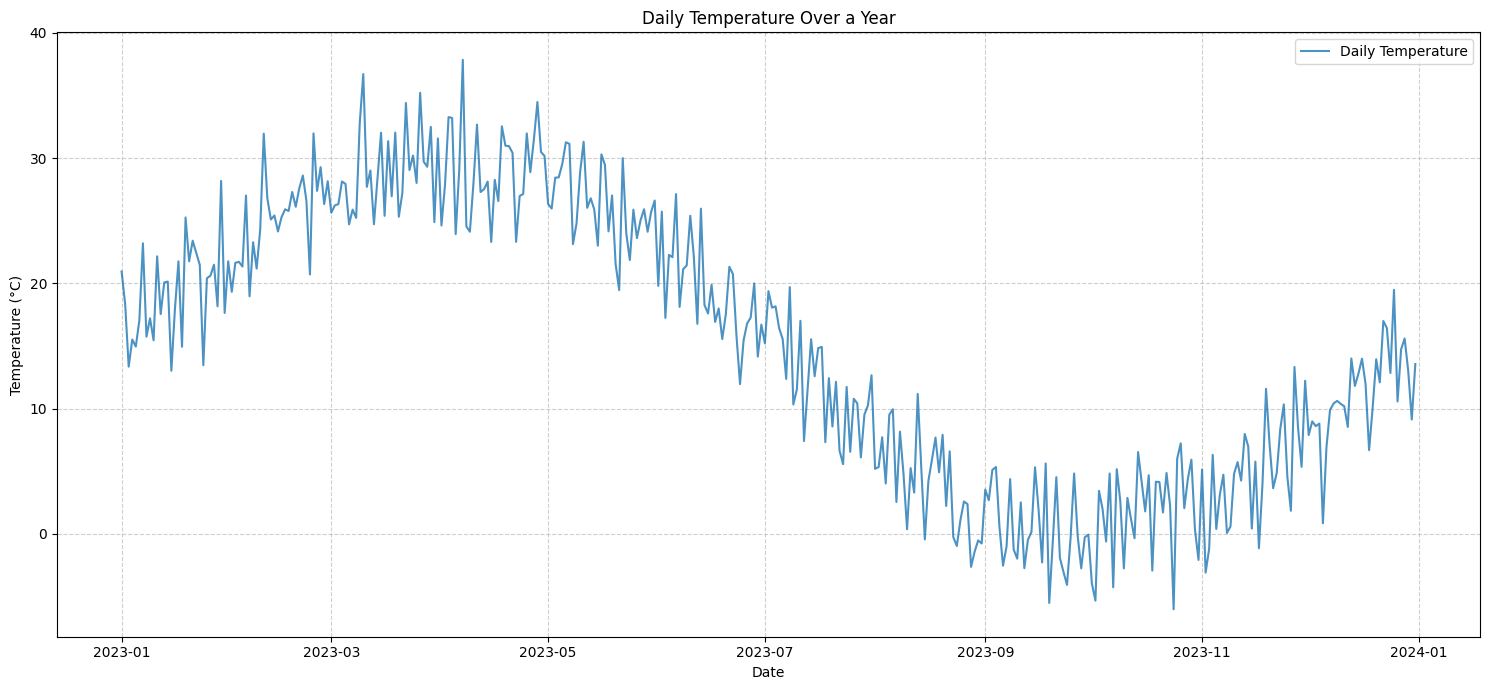

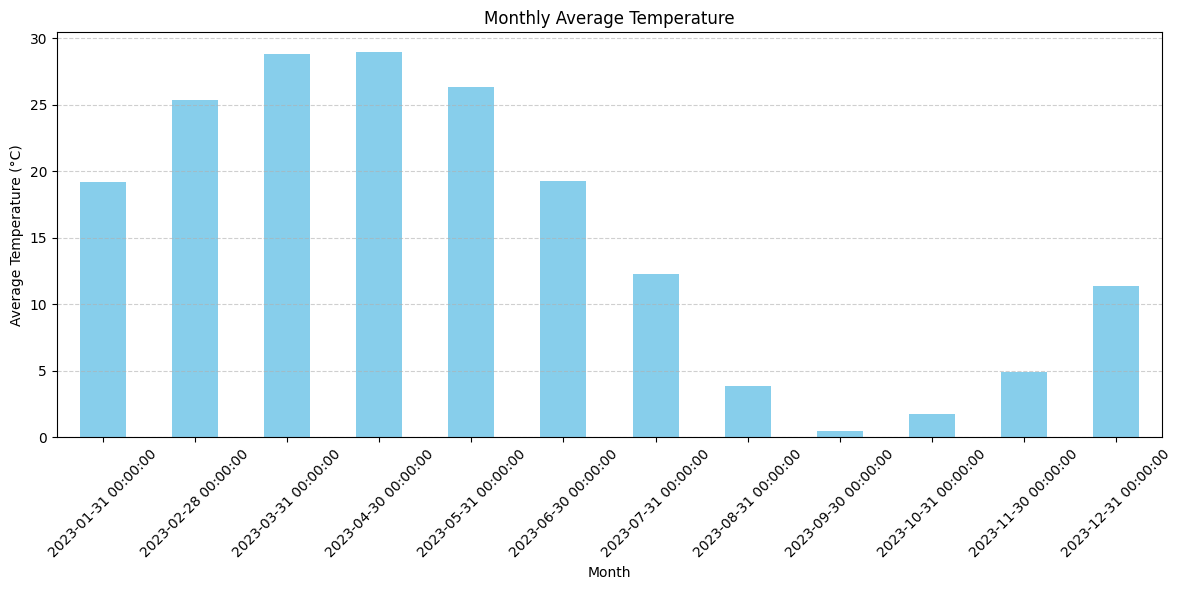

In [42]:
# Plot the daily temperature time series
plt.figure(figsize=(15, 7))
plt.plot(temperature_df.index, temperature_df['Temperature'], label='Daily Temperature', alpha=0.8)
plt.title('Daily Temperature Over a Year')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Plot the monthly average temperatures (bar plot)
plt.figure(figsize=(12, 6))
monthly_avg_temp.plot(kind='bar', color='skyblue')
plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()